In [6]:
!pip install control
!pip install matplotlib

In [2]:
import control as clt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Define pendulum constants
m = 0.2 # mass of pendulum
M = 0.5 # mass of cart
l = 0.3 # length of pendulum 
I = m*pow((2*l),2)/12 # Moment of inertia (COM) [m*(2l)ˆ2]/12
J = I + m*l*l # 0.006 + 0.2*0.3*0.3 Icom + mlˆ2 (Parallel axis theorm)
g = 9.8
print(I, J)

0.005999999999999999 0.023999999999999997


In [4]:
"""
    (M+m)x'' + mL*Cos(phi).phi'' = u + ML*Sin(phi).(phi')ˆ2        
    mL*Cos(phi)x'' + (I+mlˆ2)*phi'' = mgLSin(phi)

    We calculate [x'' phi'']

    Discrete LTI equation
    X[k+1] = Ad*x[k] + Bd*u[k]
    
"""
D_denom = (M+m)*J - (m*m*l*l)
A = np.array([
    [0, 1, 0, 0],
    [0, 0, -1*(m*m*g*l*l)/D_denom, 0],
    [0, 0, 0, 1],
    [0, 0, (M+m)*m*g*l/D_denom, 0]
])

B = np.array([
    [0],
    [(J)/D_denom],
    [0],
    [-1*m*l/D_denom]
])
C = np.eye(4)
D = np.zeros((4,1))
Q = np.diag([1, 1, 100, 100])
R = np.array([[100]])
I = np.eye(4)

In [5]:
def get_discrete_system(A, B, C, D, t=0.30):
    sys_c =clt.ss(A, B, C, D)
    return clt.c2d(sys_c, t, method='zoh')

In [6]:
"""
    Todo Bryson & Ho – Applied Optimal Control (1975)
"""

Q_R_modes = [
    {
        "label": "Angle priority",
        "Q": np.diag([1, 1, 100, 10]),
        "R": np.array([[1]])
    },
    {
        "label": "Position priority",
        "Q": np.diag([100, 10, 1, 1]),
        "R": np.array([[2]])
    },
    {
        "label": "Aggresive control",
        "Q": np.diag([100, 10, 100, 10]),
        "R": np.array([[0.1]])
    },
    {
        "label": "Energy saving",
        "Q": np.diag([1, 1, 10, 1]),
        "R": np.array([[10]])
    },
]

,mode,sampling_ms,max_misses,K0,K1,K2,K3
4,Angle priority,30.0,19,-0.730508,-1.631186,-21.128060,-4.365921
35,Position priority,30.0,5,-5.444226,-5.148527,-28.049884,-5.411376
66,Aggresive control,30.0,0,-14.068505,-12.776095,-56.818255,-11.712423
97,Energy saving,30.0,19,-0.262769,-0.714403,-15.089632,-2.768234


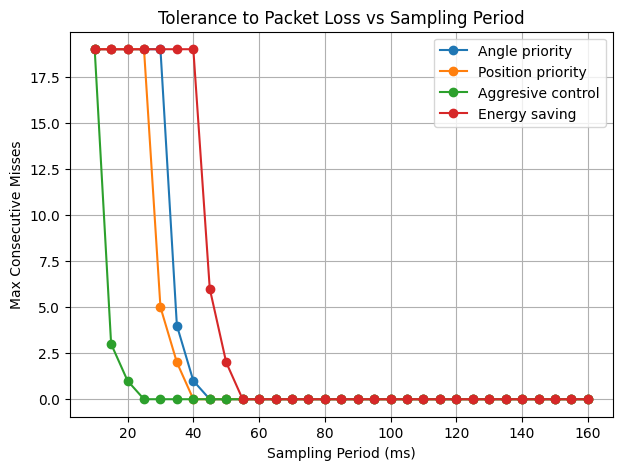

In [36]:
sampling_periods = np.arange(0.01, 0.161, 0.005)
plt.figure(figsize=(7,5))

records = []

for mode in Q_R_modes:
    Q = mode.get("Q")
    R = mode.get("R")
    max_misses_list = []
    for h in sampling_periods:
        system = get_discrete_system(A, B, C, D, t=h)
        K, _, _ = clt.dlqr(system.A, system.B, Q, R)
        # print(K)
        A_d = system.A
        B_d = system.B
        n = A.shape[0]
        I = np.eye(n)
        Z = np.zeros((n,n))
        
        A_hit = np.block([
            [A_d, -1*B_d@K, Z],
            [I, Z, Z],
            [Z, I, Z]
        ])
        A_miss = np.block([
            [A_d, Z, -1*B_d@K],
            [I, Z, Z],
            [Z, I, Z]
        ])
        
        miss = 0
        for i in range(1, 20):
            Phi = np.linalg.matrix_power(A_miss, i)@A_hit
            Rho = max(abs(np.linalg.eigvals(Phi)))
            if Rho > 1:
                break
            miss = i
        max_misses_list.append(miss)
        
        records.append({
                "mode": mode["label"],
                "sampling_ms": round(h * 1000, 3),
                "max_misses": miss,
                **{f"K{i}": v for i, v in enumerate(K.flatten())}
            })


    plt.plot(sampling_periods*1000, max_misses_list, marker='o', label=mode.get("label"))


df = pd.DataFrame(records)
filtered_df = df[df["sampling_ms"] == 30.0]
display(filtered_df)

plt.xlabel("Sampling Period (ms)")
plt.ylabel("Max Consecutive Misses")
plt.title("Tolerance to Packet Loss vs Sampling Period")

plt.legend()
plt.grid(True)

plt.show()

In [12]:
system = get_discrete_system(A, B, C, D, t=0.030)
K_mode1 = np.array([[-4.193946, 	-4.046409, 	-23.934866, 	-4.589886]])
A_cl = system.A - system.B @ K_mode1
eigvals = np.linalg.eigvals(A_cl)
print("Eigenvalues:", eigvals)
print("Spectral radius:", max(abs(eigvals)))  # must be < 1 for stability

Eigenvalues: [0.82679554+0.j         0.91762065+0.05682544j 0.91762065-0.05682544j
 0.91256294+0.j        ]
Spectral radius: 0.9193784837609597


K = [[ -4.19394608  -4.04640851 -23.93486588  -4.58988576]]
Force 0.0
Force 0.0
Force 20.969730411574528
Force 20.969730411574528
Force 20.969730411574528
Force -0.33653903620209746
Force -32.62006109760277
Force -80.43980606091776
Force -128.51817063451023
Force -163.45239259343478
Force -160.37144501322865
Force -97.88747756157271
Force 40.74028974709928
Force 252.5050347421423
Force 507.2472914412974
Force 738.6775081545659
Force 847.5334415232091
Force 715.7249048317842
Force 238.49765227285945
Force -629.2288001693247
Force -1817.9259196018397
Force -3096.20452642256
Force -4052.376892898669
Force -4130.685414493433
Force -2743.2368437284726
Force 534.8415401444106
Force 5705.8013642722835
Force 12079.215811517994
Force 18083.93585110512
Force 21283.185546512526
Force 18716.707804989335
Force 7652.797440582268
Force -13264.42185455502
Force -42641.41590795163
Force -75094.86560393522
Force -100684.1903314974
Force -105653.68598881915
Force -75046.36725573184
Force 2576.68505466452

/var/folders/pz/d1g_pynn2698jdxltndvqcn00000gn/T/ipykernel_28056/2340091136.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  u[k] = -K @ x[:,k-2]


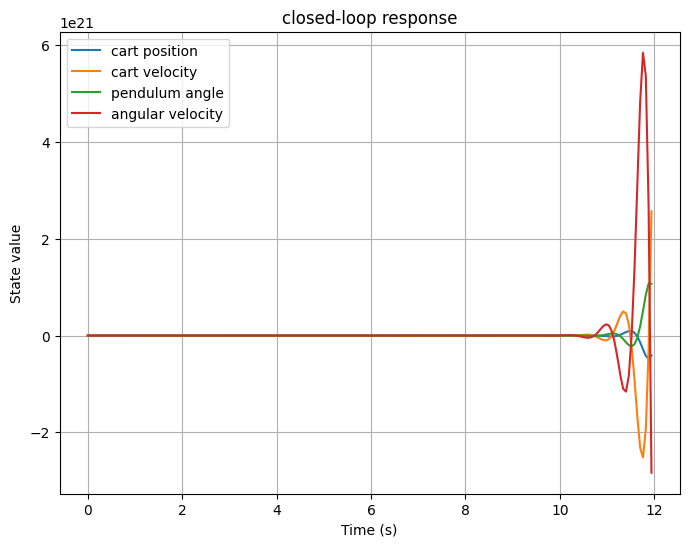

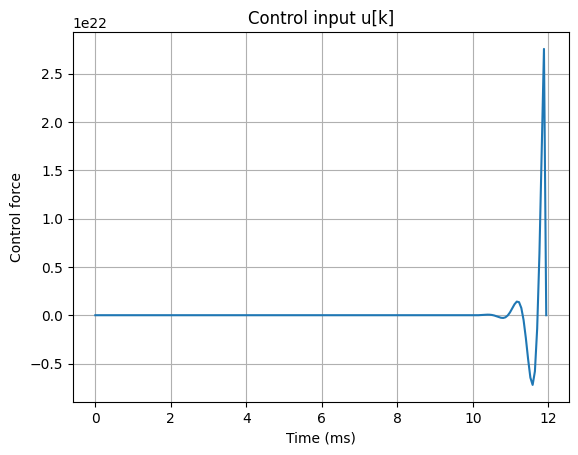

In [37]:
Q = np.diag([100, 10, 1, 1])
R = np.array([[2]])
Ts = 0.06

# Continuous system
sys_c = clt.ss(
    A, B, C, D,
    states=['x','v','theta','omega'],
    inputs=['u'],
    outputs=['x','v','theta','omega']
)

# Discretize
sys_d = clt.c2d(sys_c, Ts)

A_d = sys_d.A
B_d = sys_d.B

# LQR controller
K, S, E = clt.dlqr(A_d, B_d, Q, R)

print("K =", K)

# Simulation settings
steps = 200
t = np.arange(steps) * Ts

# State storage
x = np.zeros((4, steps))
u = np.zeros(steps)

# Initial state
x[:,0] = [5,0,0,0]

u[0] = 0
u[1] = 0
# Closed loop simulation
for k in range(steps-1):

    if k > 1:
        # control input
        u[k] = -K @ x[:,k-2]

    # next state
    x[:,k+1] = A_d @ x[:,k] + B_d.flatten() * u[k]
    # print(x[:, k+1])
    print("Force", u[k])

print(u[:20])
# Plot states
plt.figure(figsize=(8,6))

plt.plot(t, x[0], label="cart position")
plt.plot(t, x[1], label="cart velocity")
plt.plot(t, x[2], label="pendulum angle")
plt.plot(t, x[3], label="angular velocity")

plt.xlabel("Time (s)")
plt.ylabel("State value")
plt.title("closed-loop response")

plt.legend()
plt.grid(True)

plt.show()

# Plot control force
plt.figure()

plt.plot(t, u)
plt.xlabel("Time (ms)")
plt.ylabel("Control force")
plt.title("Control input u[k]")

plt.grid(True)

plt.show()